<a href="https://colab.research.google.com/github/ClickDgo/intro/blob/main/Proyecto_Maestr%C3%ADa_(Estad%C3%ADsticas_Descriptivas)_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BASE ORIGINAL
Registros: 75,603
Variables: 13

BASE DESPUÉS DE EXCLUSIONES
Registros: 74,553

Categorías de Escolaridad:
Escolaridad
Primaria completa                         17690
Primaria incompleta                       16089
Secundaria completa                       11375
Sin escolaridad                           11068
Profesional                                5986
Bachillerato o preparatoria completo       5870
Secundaria incompleta                      2208
No especificado                            2122
Bachillerato o preparatoria incompleto     1660
Posgrado                                    411
Preescolar                                   74
Name: count, dtype: int64

Categorías de Ocupación:
Ocupacion
No especificado / fuera de clasificación    47686
Agropecuario y pesca                         6534
Construcción y manufactura                   5415
Comercio y ventas                            5090
Operadores y transporte                      2498
Trabajo elemental y apoyo  

,Métrica,Valor
0,Media,0.000000
1,Desviación estándar,12.686627
2,Mediana,0.614229
3,Asimetría,-0.398616
4,Curtosis de Pearson,3.700920
5,Curtosis excedente,0.700920
6,Jarque-Bera,3499.842428
7,p Jarque-Bera,0.000000
8,Omnibus,2693.589899
9,p Omnibus,0.000000



HOMOGENEIDAD DE VARIANZAS


,Variable,Levene_W,Levene_p,Brown_Forsythe_W,Brown_Forsythe_p
0,Causa,1711.3829,0.0000e+00,1402.7017,0.0000e+00
1,Sexo,4360.0753,0.0000e+00,3726.6610,0.0000e+00
2,Escolaridad,348.8117,0.0000e+00,336.3802,0.0000e+00
3,Ocupacion,65.6576,5.0259e-147,66.7281,1.5854e-149
4,EstadoCivil,2972.1325,0.0000e+00,2790.7782,0.0000e+00


<Figure size 800x700 with 0 Axes>

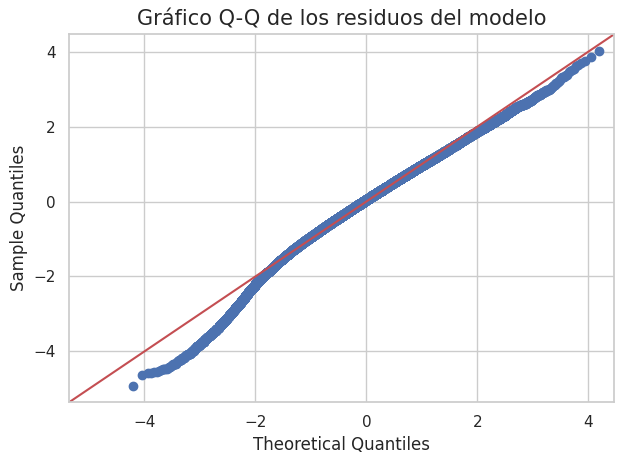

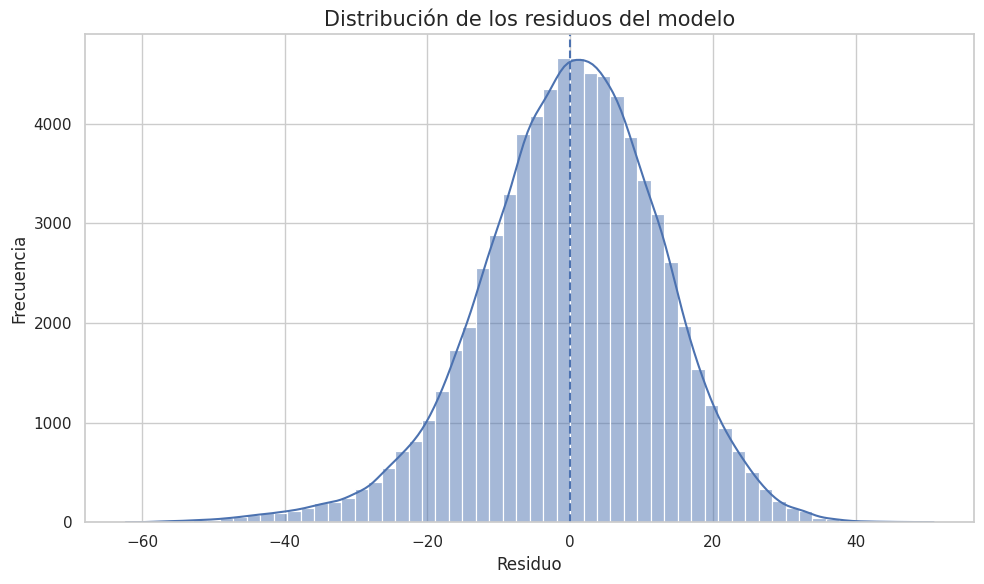

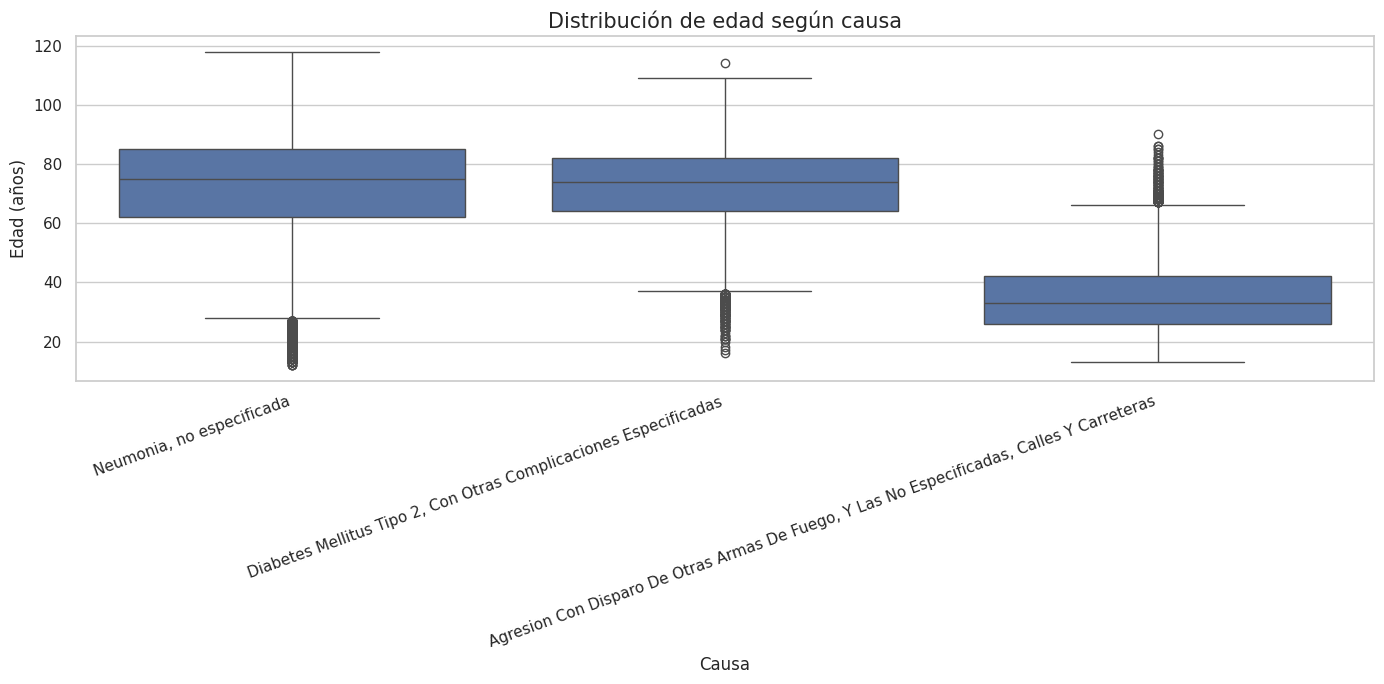

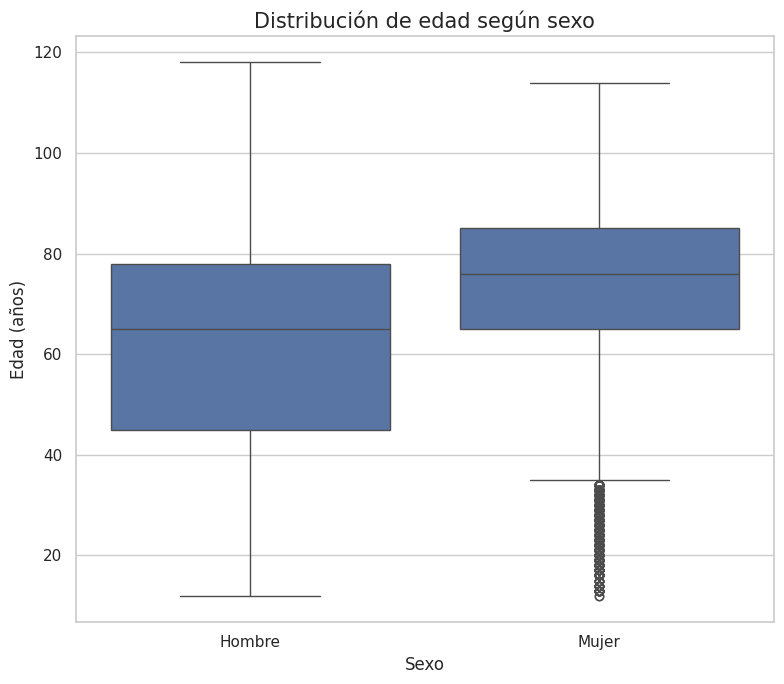

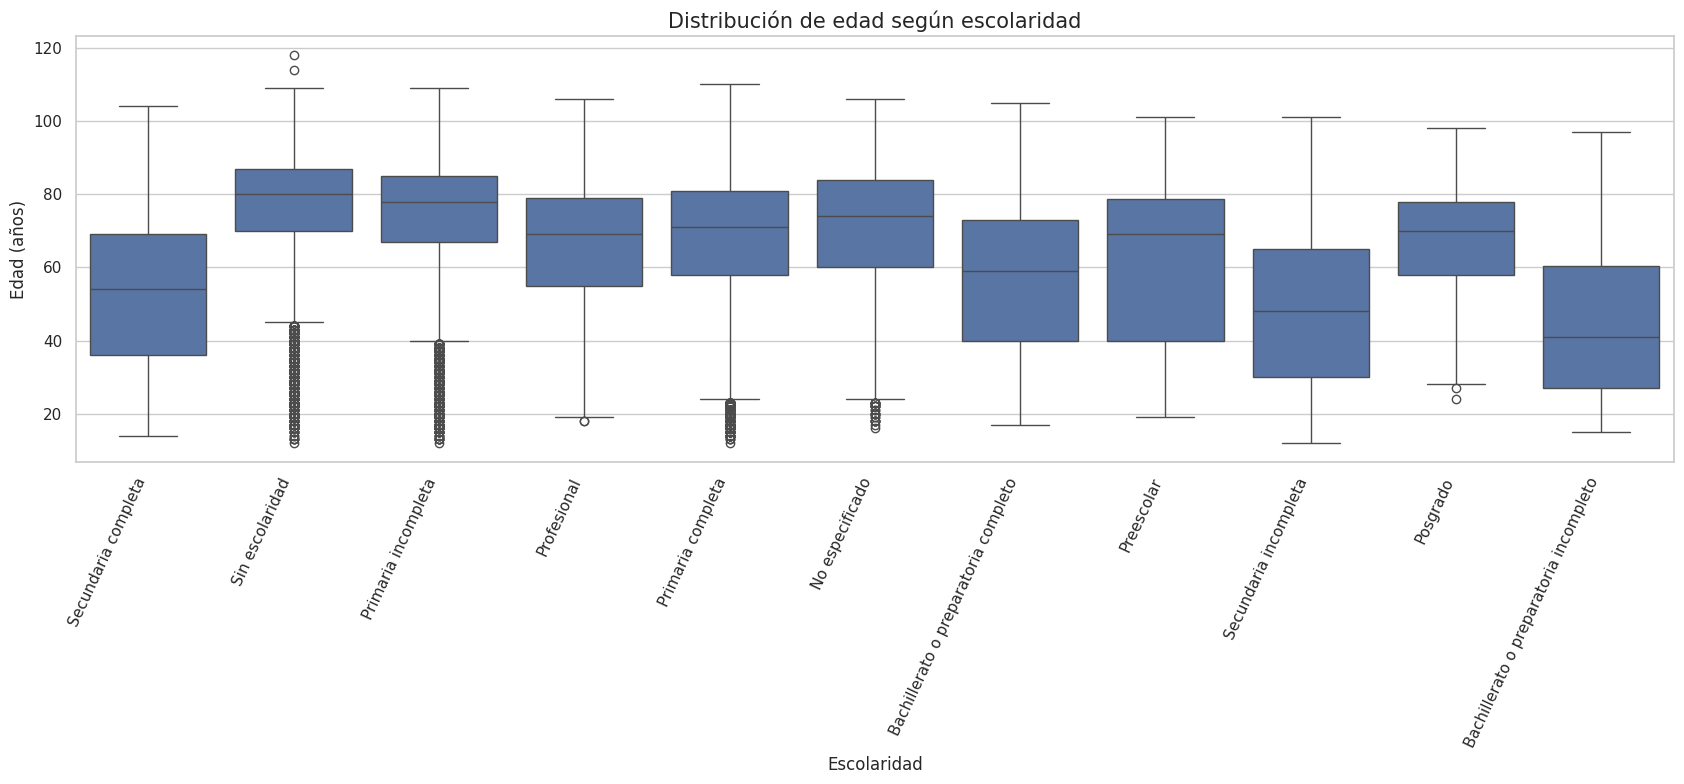

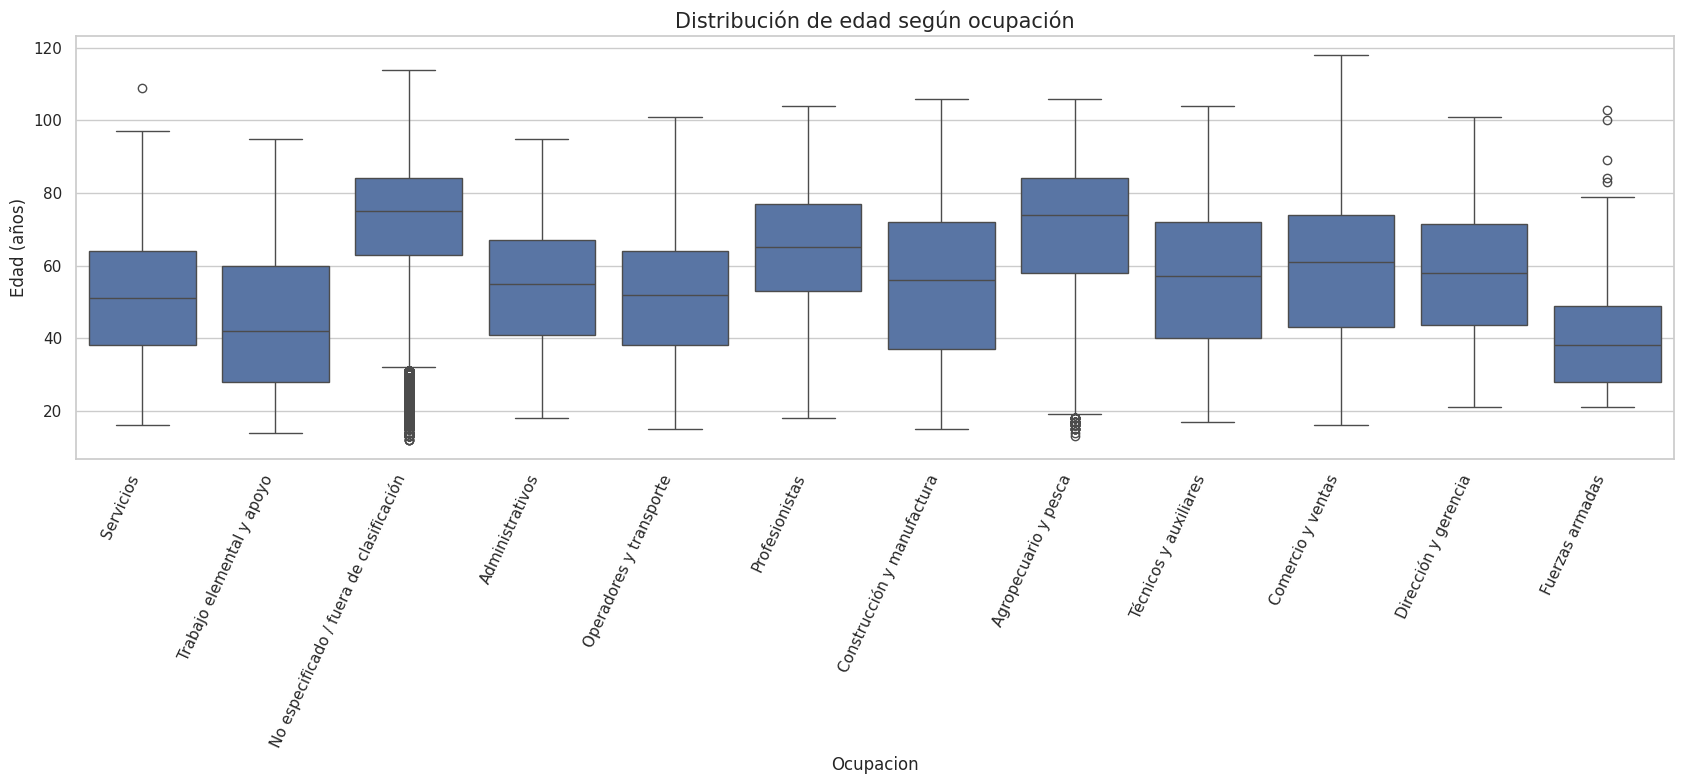

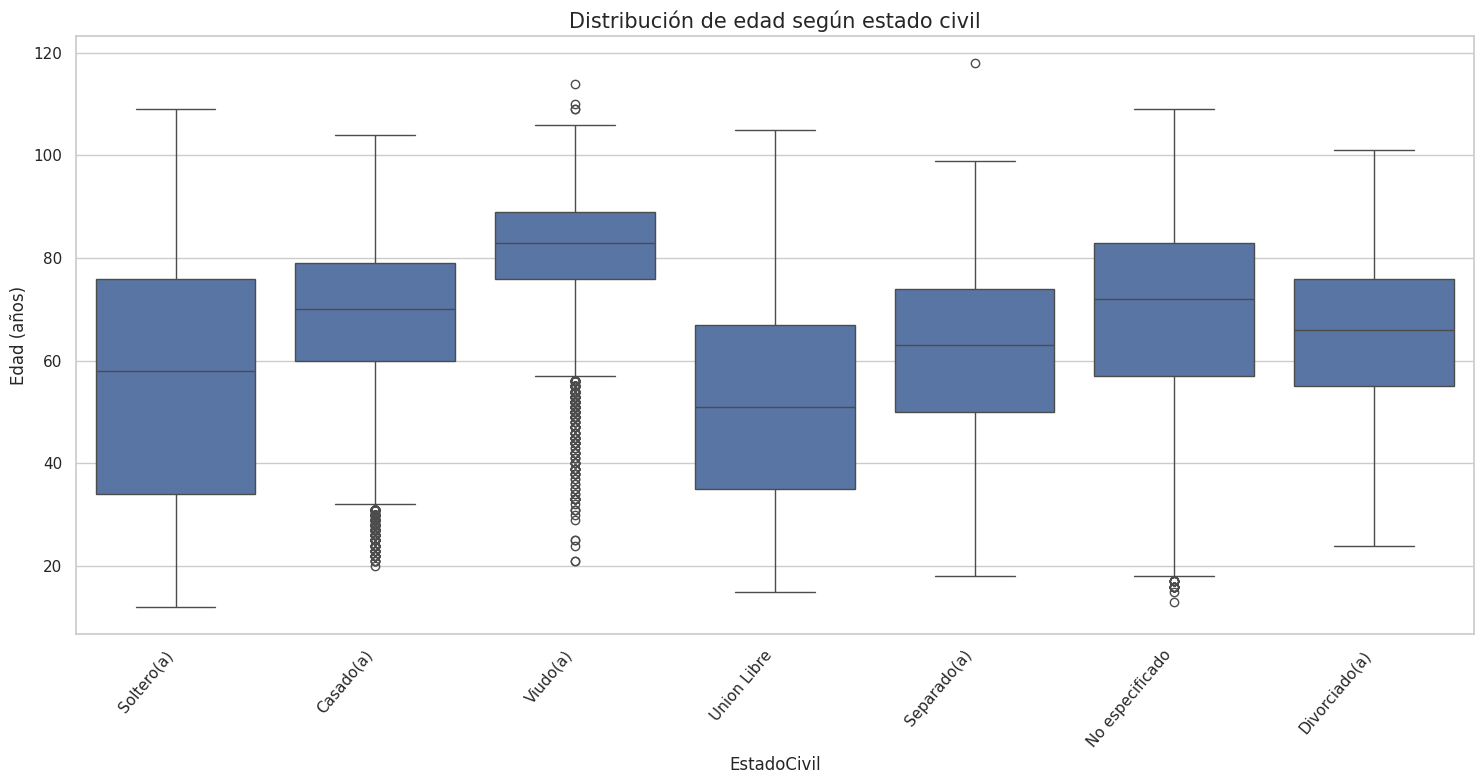

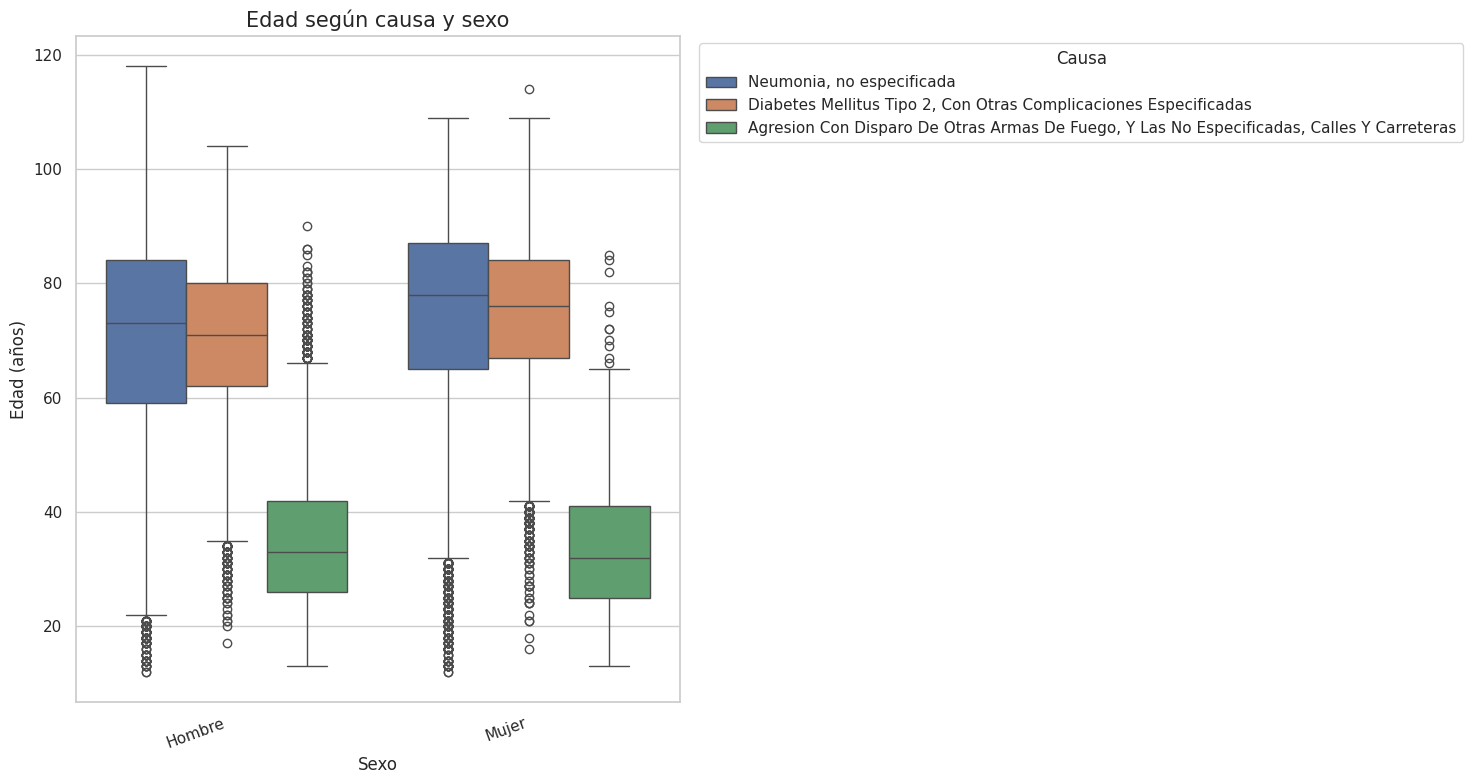

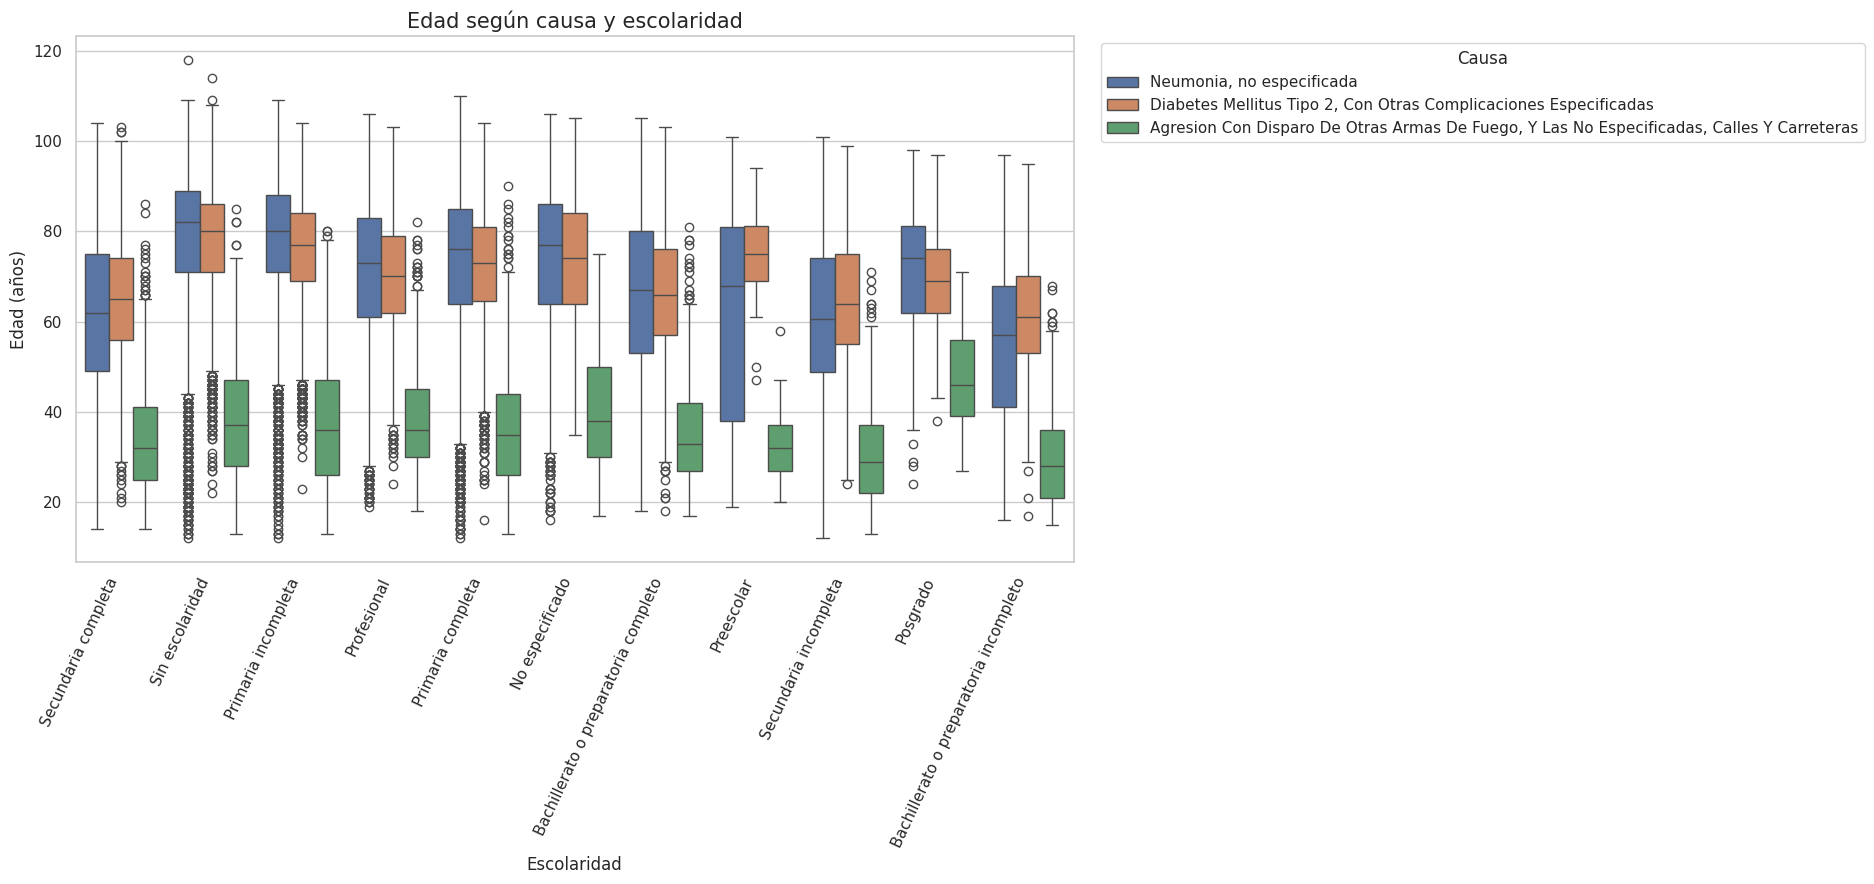

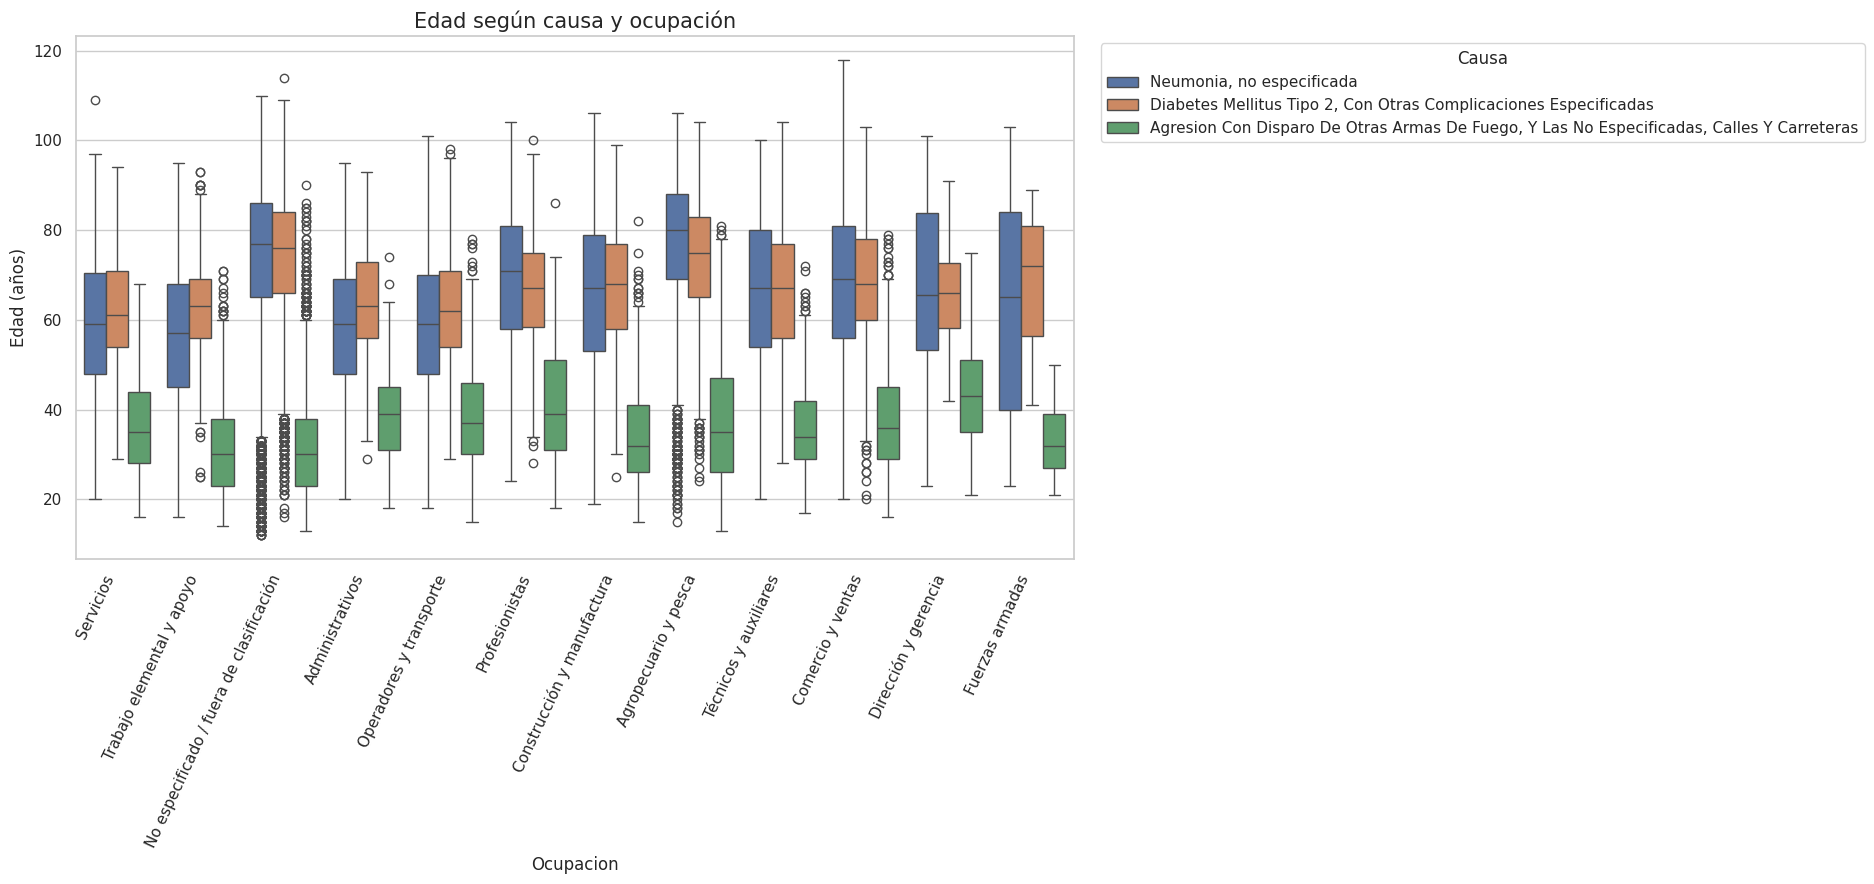

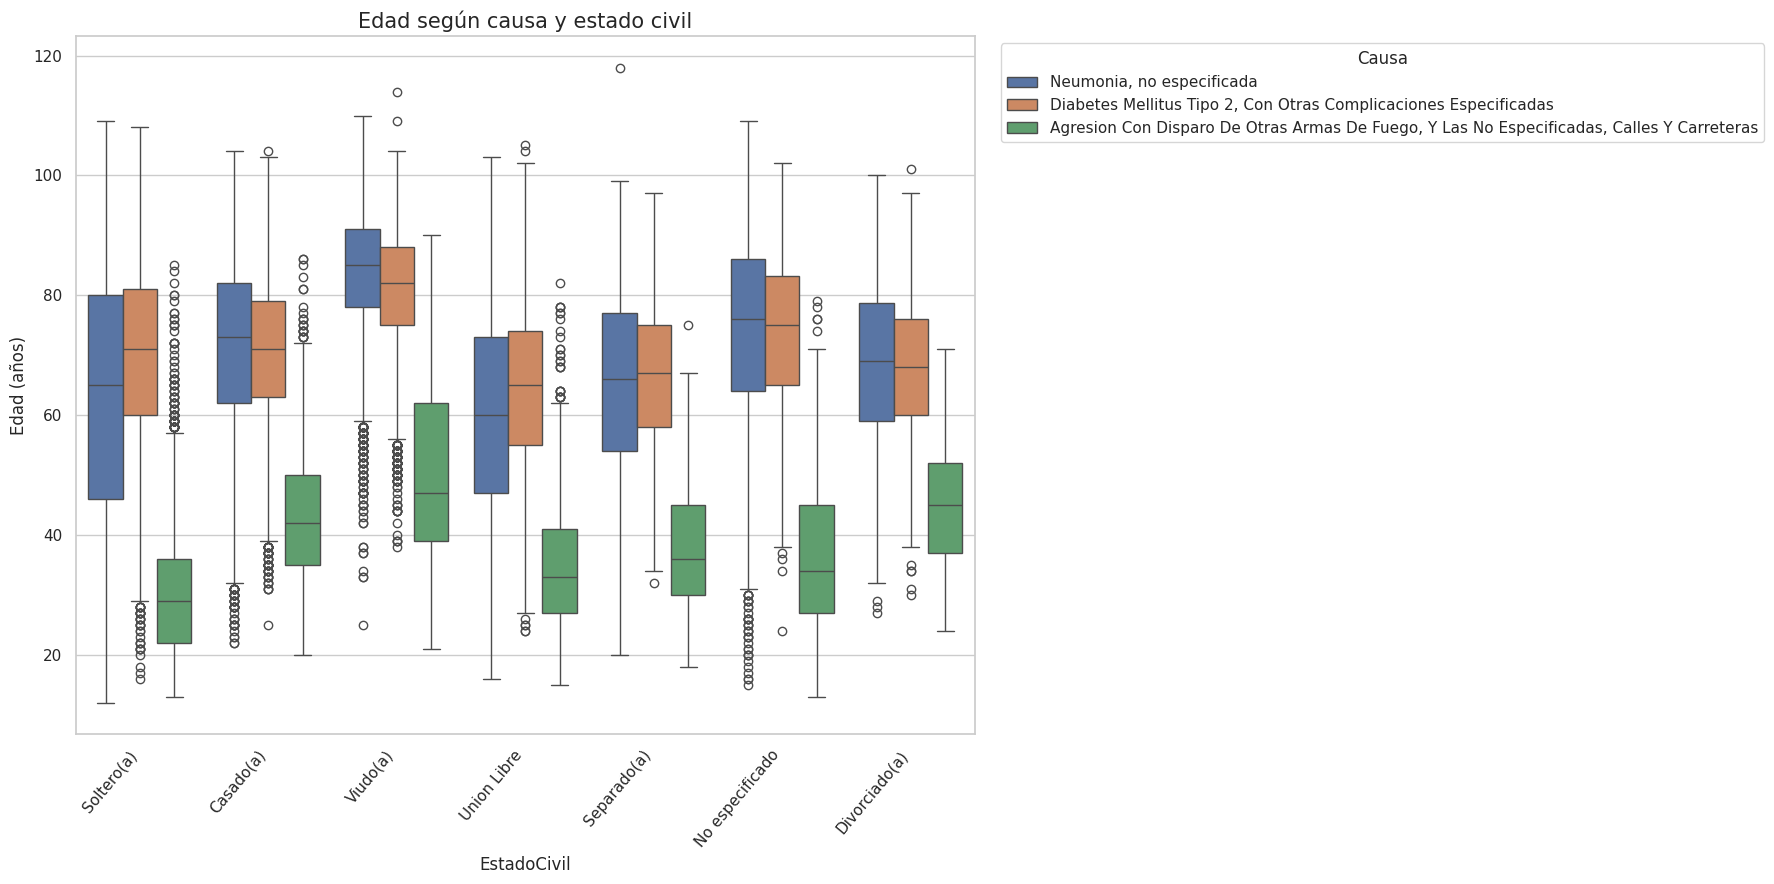


RESULTADOS DEL MODELO CON ERRORES ROBUSTOS HC3


,Coeficiente,Error_Estandar_HC3,t_HC3,p_HC3,IC_95_inf,IC_95_sup
Intercept,35.9132,0.5981,60.0417,0.0000e+00,34.7408,37.0855
"C(Causa)[T.Diabetes Mellitus Tipo 2, Con Otras Complicaciones Especificadas]",27.0327,0.1536,176.0355,0.0000e+00,26.7317,27.3337
"C(Causa)[T.Neumonia, no especificada]",26.8515,0.1719,156.1838,0.0000e+00,26.5146,27.1885
C(Sexo)[T.Mujer],0.3247,0.1210,2.6831,7.2969e-03,0.0875,0.5620
C(Escolaridad)[T.Bachillerato o preparatoria incompleto],-5.1991,0.3572,-14.5564,6.1941e-48,-5.8992,-4.4991
C(Escolaridad)[T.No especificado],5.9454,0.3620,16.4231,1.6699e-60,5.2359,6.6550
C(Escolaridad)[T.Posgrado],5.3217,0.6498,8.1894,2.6666e-16,4.0480,6.5953
C(Escolaridad)[T.Preescolar],1.7136,1.9940,0.8593,3.9016e-01,-2.1948,5.6219
C(Escolaridad)[T.Primaria completa],4.7948,0.2043,23.4661,2.4993e-121,4.3944,5.1953
C(Escolaridad)[T.Primaria incompleta],8.2493,0.2077,39.7248,0.0000e+00,7.8423,8.6563



RESUMEN DEL MODELO HC3
N = 74,553
R² = 0.6028
R² ajustado = 0.6027
Covarianza = HC3

Modelo:
Edad ~ Causa + Sexo + Escolaridad + Ocupacion + EstadoCivil


In [26]:
# ============================================================
# ANÁLISIS DE EDAD
# ANOVA FACTORIAL + DIAGNÓSTICO DE RESIDUOS + BOXPLOTS + HC3
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.oneway import anova_oneway

# ============================================================
# 1. CARGAR BASE
# ============================================================

df = pd.read_csv(
    "/content/Defunciones.csv",
    encoding="latin1"
)

# Edad numérica
df["Edad"] = pd.to_numeric(df["Edad"], errors="coerce")

# Eliminar edades faltantes
df = df.dropna(subset=["Edad"]).copy()

print("=" * 75)
print("BASE ORIGINAL")
print("=" * 75)
print(f"Registros: {len(df):,}")
print(f"Variables: {df.shape[1]}")


# ============================================================
# 2. ELIMINAR CATEGORÍAS QUE NO QUEREMOS ANALIZAR
# ============================================================

df = df[
    df["Escolaridad"] != "No aplica a menores de 3"
].copy()

df = df[
    df["Ocupacion"] != "No especificado/fuera de clasificación"
].copy()

df = df[
    df["EstadoCivil"] != "No aplica a menores de 12"
].copy()

print("\n" + "=" * 75)
print("BASE DESPUÉS DE EXCLUSIONES")
print("=" * 75)
print(f"Registros: {len(df):,}")

print("\nCategorías de Escolaridad:")
print(df["Escolaridad"].value_counts())

print("\nCategorías de Ocupación:")
print(df["Ocupacion"].value_counts())

print("\nCategorías de Estado Civil:")
print(df["EstadoCivil"].value_counts())


# ============================================================
# 3. MODELO ANOVA FACTORIAL
# ============================================================
#
# Edad es la variable respuesta.
#
# Se incluyen como factores:
# Causa
# Sexo
# Escolaridad
# Ocupacion
# EstadoCivil
#
# No incluimos interacciones todavía.
# Primero analizamos el efecto conjunto de los factores.
# ============================================================

formula = """
Edad ~ C(Causa)
     + C(Sexo)
     + C(Escolaridad)
     + C(Ocupacion)
     + C(EstadoCivil)
"""

modelo = smf.ols(formula, data=df).fit()

residuos = modelo.resid

print("\n" + "=" * 75)
print("MODELO ANOVA / OLS")
print("=" * 75)

print(f"N = {int(modelo.nobs):,}")
print(f"R² = {modelo.rsquared:.4f}")
print(f"R² ajustado = {modelo.rsquared_adj:.4f}")
print(f"Grados de libertad del residuo = {int(modelo.df_resid):,}")


# ============================================================
# 4. DIAGNÓSTICO DE NORMALIDAD DE LOS RESIDUOS
# ============================================================

media_res = residuos.mean()
sd_res = residuos.std()
mediana_res = residuos.median()

asimetria = stats.skew(residuos, bias=False)

# Curtosis de Pearson
curtosis_pearson = stats.kurtosis(
    residuos,
    fisher=False,
    bias=False
)

# Curtosis excedente
curtosis_exceso = stats.kurtosis(
    residuos,
    fisher=True,
    bias=False
)

# Jarque-Bera
jb_stat, jb_p = stats.jarque_bera(residuos)

# Omnibus D'Agostino-Pearson
omnibus_stat, omnibus_p = stats.normaltest(residuos)

# Shapiro-Wilk
# Con muestras muy grandes SciPy advierte que el p-valor
# puede no ser preciso; aun así lo reportamos.
shapiro_n = min(len(residuos), 5000)

shapiro_stat, shapiro_p = stats.shapiro(
    residuos.sample(shapiro_n, random_state=123)
)

tabla_normalidad = pd.DataFrame({
    "Métrica": [
        "Media",
        "Desviación estándar",
        "Mediana",
        "Asimetría",
        "Curtosis de Pearson",
        "Curtosis excedente",
        "Jarque-Bera",
        "p Jarque-Bera",
        "Omnibus",
        "p Omnibus",
        "Shapiro-Wilk (muestra máx. 5000)",
        "p Shapiro-Wilk"
    ],
    "Valor": [
        media_res,
        sd_res,
        mediana_res,
        asimetria,
        curtosis_pearson,
        curtosis_exceso,
        jb_stat,
        jb_p,
        omnibus_stat,
        omnibus_p,
        shapiro_stat,
        shapiro_p
    ]
})

print("\n" + "=" * 75)
print("DIAGNÓSTICO DE NORMALIDAD DE LOS RESIDUOS")
print("=" * 75)

display(
    tabla_normalidad.style.format({
        "Valor": "{:.6f}"
    })
)


# ============================================================
# 5. HOMOGENEIDAD DE VARIANZAS
# ============================================================
#
# Levene y Brown-Forsythe.
#
# Para evitar construir una combinación gigantesca de todos
# los factores, evaluamos la variabilidad de Edad respecto
# de cada factor individual.
# ============================================================

def pruebas_varianza(data, variable):

    grupos = [
        grupo["Edad"].values
        for _, grupo in data.groupby(variable, observed=True)
        if len(grupo) > 1
    ]

    # Levene centrado en la media
    lev_stat, lev_p = stats.levene(
        *grupos,
        center="mean"
    )

    # Brown-Forsythe = Levene centrado en mediana
    bf_stat, bf_p = stats.levene(
        *grupos,
        center="median"
    )

    return [
        variable,
        lev_stat,
        lev_p,
        bf_stat,
        bf_p
    ]


resultados_varianza = []

for variable in [
    "Causa",
    "Sexo",
    "Escolaridad",
    "Ocupacion",
    "EstadoCivil"
]:

    resultados_varianza.append(
        pruebas_varianza(df, variable)
    )

tabla_varianza = pd.DataFrame(
    resultados_varianza,
    columns=[
        "Variable",
        "Levene_W",
        "Levene_p",
        "Brown_Forsythe_W",
        "Brown_Forsythe_p"
    ]
)

print("\n" + "=" * 75)
print("HOMOGENEIDAD DE VARIANZAS")
print("=" * 75)

display(
    tabla_varianza.style.format({
        "Levene_W": "{:.4f}",
        "Levene_p": "{:.4e}",
        "Brown_Forsythe_W": "{:.4f}",
        "Brown_Forsythe_p": "{:.4e}"
    })
)


# ============================================================
# 6. GRÁFICO Q-Q DE LOS RESIDUOS
# ============================================================

plt.figure(figsize=(8, 7))

sm.qqplot(
    residuos,
    line="45",
    fit=True
)

plt.title(
    "Gráfico Q-Q de los residuos del modelo",
    fontsize=15
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. HISTOGRAMA DE RESIDUOS
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    residuos,
    bins=60,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Distribución de los residuos del modelo",
    fontsize=15
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


# ============================================================
# 8. BOXPLOTS: EDAD POR CADA VARIABLE
# ============================================================

sns.set_theme(style="whitegrid")

graficos = [
    ("Causa", "Distribución de edad según causa", 14, 7, 20),
    ("Sexo", "Distribución de edad según sexo", 8, 7, 0),
    ("Escolaridad", "Distribución de edad según escolaridad", 17, 8, 65),
    ("Ocupacion", "Distribución de edad según ocupación", 17, 8, 65),
    ("EstadoCivil", "Distribución de edad según estado civil", 15, 8, 50)
]

for variable, titulo, ancho, alto, rotacion in graficos:

    plt.figure(figsize=(ancho, alto))

    sns.boxplot(
        data=df,
        x=variable,
        y="Edad"
    )

    plt.title(titulo, fontsize=15)
    plt.xlabel(variable)
    plt.ylabel("Edad (años)")

    if rotacion:
        plt.xticks(
            rotation=rotacion,
            ha="right"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. BOXPLOTS: CAUSA × CADA VARIABLE
# ============================================================

cruces = [
    ("Sexo", "Edad según causa y sexo", 15, 8, 20),
    ("Escolaridad", "Edad según causa y escolaridad", 19, 9, 65),
    ("Ocupacion", "Edad según causa y ocupación", 19, 9, 65),
    ("EstadoCivil", "Edad según causa y estado civil", 18, 9, 50)
]

for variable, titulo, ancho, alto, rotacion in cruces:

    plt.figure(figsize=(ancho, alto))

    sns.boxplot(
        data=df,
        x=variable,
        y="Edad",
        hue="Causa"
    )

    plt.title(titulo, fontsize=15)
    plt.xlabel(variable)
    plt.ylabel("Edad (años)")

    if rotacion:
        plt.xticks(
            rotation=rotacion,
            ha="right"
        )

    plt.legend(
        title="Causa",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. MODELO CON ERRORES ROBUSTOS HC3
# ============================================================

modelo_hc3 = modelo.get_robustcov_results(
    cov_type="HC3"
)

# Obtener nombres de coeficientes
nombres = modelo.model.exog_names

tabla_hc3 = pd.DataFrame({
    "Coeficiente": modelo_hc3.params,
    "Error_Estandar_HC3": modelo_hc3.bse,
    "t_HC3": modelo_hc3.tvalues,
    "p_HC3": modelo_hc3.pvalues,
    "IC_95_inf": modelo_hc3.conf_int()[:, 0],
    "IC_95_sup": modelo_hc3.conf_int()[:, 1]
}, index=nombres)

print("\n" + "=" * 75)
print("RESULTADOS DEL MODELO CON ERRORES ROBUSTOS HC3")
print("=" * 75)

display(
    tabla_hc3.style.format({
        "Coeficiente": "{:.4f}",
        "Error_Estandar_HC3": "{:.4f}",
        "t_HC3": "{:.4f}",
        "p_HC3": "{:.4e}",
        "IC_95_inf": "{:.4f}",
        "IC_95_sup": "{:.4f}"
    })
)


# ============================================================
# 11. RESUMEN HC3
# ============================================================

print("\n" + "=" * 75)
print("RESUMEN DEL MODELO HC3")
print("=" * 75)

print(f"N = {int(modelo.nobs):,}")
print(f"R² = {modelo.rsquared:.4f}")
print(f"R² ajustado = {modelo.rsquared_adj:.4f}")
print(f"Covarianza = HC3")

print("\nModelo:")
print("Edad ~ Causa + Sexo + Escolaridad + Ocupacion + EstadoCivil")

In [29]:
import plotly.express as px

# 1. Lista de gráficos individuales y cruzados que necesitas
variables_individuales = [
    ("Causa", "Distribución de edad según causa"),
    ("Sexo", "Distribución de edad según sexo"),
    ("Escolaridad", "Distribución de edad según escolaridad"),
    ("Ocupacion", "Distribución de edad según ocupación"),
    ("EstadoCivil", "Distribución de edad según estado civil")
]

cruces = [
    ("Sexo", "Edad según causa y sexo"),
    ("Escolaridad", "Edad según causa y escolaridad"),
    ("Ocupacion", "Edad según causa y ocupación"),
    ("EstadoCivil", "Edad según causa y estado civil")
]

# 2. Estructura base del HTML con tus estilos CSS institucionales
html_completo = """<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Gráficos Interactivos - Diseño de Experimentos</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link href="https://fonts.googleapis.com/css2?family=Google+Sans:wght@400;500;600;700&display=swap" rel="stylesheet">
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
:root{--navy:#17365d;--navy2:#234f7d;--text:#202124;--muted:#6b7280;--line:#e5e7eb;--soft:#f7f9fc;}
body{margin:0;background:white;color:var(--text);font-family:"Google Sans",Arial,sans-serif;}
.container{width:min(1480px,94%);margin:auto;padding:30px 0;}
.panel{border:1px solid var(--line);border-radius:18px;background:white;margin:22px 0;overflow:hidden;}
.panel-header{padding:20px 23px 7px;}
.panel-header h3{margin:0;font-size:20px;color:var(--navy);}
.panel-body{padding:10px 18px 20px;}
h1{text-align:center;color:var(--navy);font-size:32px;margin-bottom:30px;}
</style>
</head>
<body>
<div class="container">
<h1>Gráficos Interactivos de Edad (Box Plots)</h1>
"""

# 3. Generar dinámicamente los gráficos individuales
for var, titulo in variables_individuales:
    fig = px.box(data_frame=df, x=var, y="Edad", title=titulo, color=var)
    fig.update_layout(
        font=dict(family="Google Sans, Arial", color="#202124"),
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        margin=dict(t=30, r=20, l=50, b=50),
        xaxis=dict(gridcolor="#e5e7eb", tickangle=-30 if var != "Sexo" else 0),
        yaxis=dict(title="Edad (años)", gridcolor="#e5e7eb")
    )
    # Incluir el gráfico en formato HTML sin duplicar la librería
    grafico_html = fig.to_html(include_plotlyjs=False, full_html=False)

    html_completo += f"""
    <div class="panel">
        <div class="panel-header"><h3>{titulo}</h3></div>
        <div class="panel-body">{grafico_html}</div>
    </div>
    """

# 4. Generar dinámicamente los gráficos cruzados (Causa x Factor)
for var, titulo in cruces:
    fig = px.box(data_frame=df, x=var, y="Edad", color="Causa", title=titulo)
    fig.update_layout(
        font=dict(family="Google Sans, Arial", color="#202124"),
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        margin=dict(t=30, r=20, l=50, b=50),
        xaxis=dict(gridcolor="#e5e7eb", tickangle=-30),
        yaxis=dict(title="Edad (años)", gridcolor="#e5e7eb"),
        legend_title="Causa"
    )
    grafico_html = fig.to_html(include_plotlyjs=False, full_html=False)

    html_completo += f"""
    <div class="panel">
        <div class="panel-header"><h3>{titulo}</h3></div>
        <div class="panel-body">{grafico_html}</div>
    </div>
    """

html_completo += """
</div>
</body>
</html>
"""

# 5. Guardar todo en un solo archivo HTML listo para abrir
with open("todos_los_graficos.html", "w", encoding="utf-8") as f:
    f.write(html_completo)

print("¡Listo! Se han generado todos los gráficos interactivos en el archivo 'todos_los_graficos.html'.")

¡Listo! Se han generado todos los gráficos interactivos en el archivo 'todos_los_graficos.html'.
